In [23]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [24]:
import torch
import json
import os
from torch_geometric.nn import global_mean_pool
import src.global_config as global_cfg
import src.stats.config as cfg
import src.gnn.config as ecfg
import src.gnn.model as sage
import src.gnn.data_loader as gnnDataLoader
import src.gnn.train as train
import src.gnn.pipeline as pipeline
import src.gnn.analysis as eanalysis
import src.gnn.visualization as eviz
import src.stats.analysis as stat_analysis
import src.stats.visualization as stat_viz

In [25]:
with open("./Data/BN/network_2003.json", "r") as f:
    raw_json = json.load(f)
feature_mode = ecfg.FEATURE_MODE
snapshot_2003 = gnnDataLoader.json_to_pyg_data(raw_json, feature_mode=feature_mode)
print(f"Snapshot creado: {snapshot_2003}")
print(f"Nodos: {snapshot_2003.num_nodes}, Features: {snapshot_2003.num_node_features}")

Snapshot creado: Data(x=[397, 1], edge_index=[2, 396], edge_attr=[396, 1])
Nodos: 397, Features: 1


In [26]:
data = snapshot_2003
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Usando dispositivo:", device)
data = data.to(device)

Usando dispositivo: cpu


In [27]:


model = sage.GraphSAGEEncoder(ecfg.IN_CHANNELS, ecfg.HIDDEN_CHANNELS, ecfg.OUT_CHANNELS, ecfg.DROPOUT_RATE).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=ecfg.LR_INITIAL, weight_decay=ecfg.WEIGHT_DECAY)
criterion = torch.nn.BCEWithLogitsLoss()

In [28]:
trained_model, auc = train.train_linkpred(model, data, optimizer,  criterion, device, epochs=200)
trained_model.eval()
with torch.no_grad():
    z = trained_model(data.x, data.edge_index)  # [num_nodes, out_channels]

embeddings = z.cpu().numpy()
print("dimension de embeddings:", embeddings.shape)  # (num_nodes, out_channels)
print(embeddings[0])

items = raw_json["network"]["items"]
clusters = [node.get("cluster", -1) for node in items]  # lista de clusters


Epoch 001 | Loss: 0.6848
Epoch 020 | Loss: 0.4623
Epoch 040 | Loss: 0.4059
Epoch 060 | Loss: 0.3914
Epoch 080 | Loss: 0.3797
Epoch 100 | Loss: 0.4022
Epoch 120 | Loss: 0.3727
Epoch 140 | Loss: 0.3733
Epoch 160 | Loss: 0.3624
Epoch 180 | Loss: 0.3638
Epoch 200 | Loss: 0.3802
dimension de embeddings: (397, 8)
[ -3.4495382  -1.8507224 -12.47237    -6.0791955  10.446445    9.678526
  10.15443     9.892904 ]


In [29]:

# z ya existe, NO usamos z_nodes aquí
ego_mask = gnnDataLoader.get_ego_mask(raw_json).to(device)

# Filtrar solo alters
z_alters = z[ego_mask]

# Nuevo batch: todos los alters pertenecen al mismo grafo
batch_alters = torch.zeros(z_alters.size(0), dtype=torch.long, device=device)

graph_embedding = global_mean_pool(z_alters, batch_alters)

print("Dimension del embedding del grafo (sin ego):", graph_embedding.shape)
print(graph_embedding)


# Crear el vector batch (todos los nodos tienen la etiqueta 0 porque es un solo grafo)
# z es la matriz de embeddings de todos los nodos, es de la forma [No.Nodos, out_channels]
print(z.shape)
#batch = torch.zeros(data.num_nodes, dtype=torch.long, device=device)

# Hacemos el pooling usando los embeddings de nodos ya entrenados (z)
# El pooling hace un "promedio" en base al tamaño del batch, en nuestro caso
# al poner batch como un tensor llenos de 0's, entonces promedia todos aquellos que tengan como indice 0 (todos los nodos)
#Devuelve una matriz de [1, 16], "comprime" todos los embeddings a uno solo
#graph_embedding = global_mean_pool(z, batch)
print("Dimension del embedding del grafo:", graph_embedding.shape)
print(graph_embedding)

Dimension del embedding del grafo (sin ego): torch.Size([1, 8])
tensor([[-0.0500, -0.0136, -0.0908, -0.0351,  0.0661,  0.0698,  0.0749,  0.0846]])
torch.Size([397, 8])
Dimension del embedding del grafo: torch.Size([1, 8])
tensor([[-0.0500, -0.0136, -0.0908, -0.0351,  0.0661,  0.0698,  0.0749,  0.0846]])


In [30]:
#Entrenar red y generar embeddings
historia, auc_mean = pipeline.run_temporal_graphsage(device)

Feature mode: ones (in_channels=1)
Warm-start: True
Pooling mode: hierarchical
Modo: con memoria
Epoch 001 | Loss: 0.7162
Epoch 020 | Loss: 0.4783
Epoch 040 | Loss: 0.4756
Epoch 060 | Loss: 0.4004
1980 procesado. (alters=26, total_nodos=27, pooling=hierarchical, AUC=1.0000)
Epoch 001 | Loss: 0.4120
Epoch 020 | Loss: 0.4415
Epoch 040 | Loss: 0.4428
Epoch 060 | Loss: 0.4120
1981 procesado. (alters=63, total_nodos=64, pooling=hierarchical, AUC=1.0000)
Epoch 001 | Loss: 0.3814
Epoch 020 | Loss: 0.3868
Epoch 040 | Loss: 0.4164
Epoch 060 | Loss: 0.4416
1982 procesado. (alters=58, total_nodos=59, pooling=hierarchical, AUC=1.0000)
Epoch 001 | Loss: 0.3834
Epoch 020 | Loss: 0.4286
Epoch 040 | Loss: 0.3900
Epoch 060 | Loss: 0.3827
1983 procesado. (alters=35, total_nodos=36, pooling=hierarchical, AUC=1.0000)
Epoch 001 | Loss: 0.4799
Epoch 020 | Loss: 0.4208
Epoch 040 | Loss: 0.4254
Epoch 060 | Loss: 0.4145
1984 procesado. (alters=45, total_nodos=46, pooling=hierarchical, AUC=1.0000)
Epoch 001 | L

In [31]:
print(graph_embedding.shape)

torch.Size([1, 8])


In [32]:
df_trayectoria = eanalysis.calcular_pca_2d(historia)
eviz.plot_trayectoria_2d(df_trayectoria)

In [33]:
df_flujo, metadatos_pca = eanalysis.calcular_pca_1d(historia)
eviz.plot_evolucion_pc1(df_flujo)

In [34]:
# Guardar serie PC1 de GraphSAGE por año
df_sage = df_flujo.rename(columns={"y_original": "sage_pc1"}).copy()
df_sage.to_csv(os.path.join(global_cfg.OUTPUT_DIR, "graphsage_pca1.csv"), index=False)
print(f"[OK] Guardado en: {global_cfg.OUTPUT_DIR}")

[OK] Guardado en: ./Output


Calculando promedios anuales de los datos crudos (sin ego)...
PC1 ya estaba alineado con 'Percent of documents'. Corr: 0.5731

Resultados de Correlación con el Eje Y PC1
WoS Categories: 0.1260
Document Types: 0.1933
Documents,: 0.3076
Ave. citations: 0.2109
Ave. authorships: -0.3997
Ave. references: 0.0183
Percent of documents: 0.5731
Percent of documents Int. Coll.: -0.2689


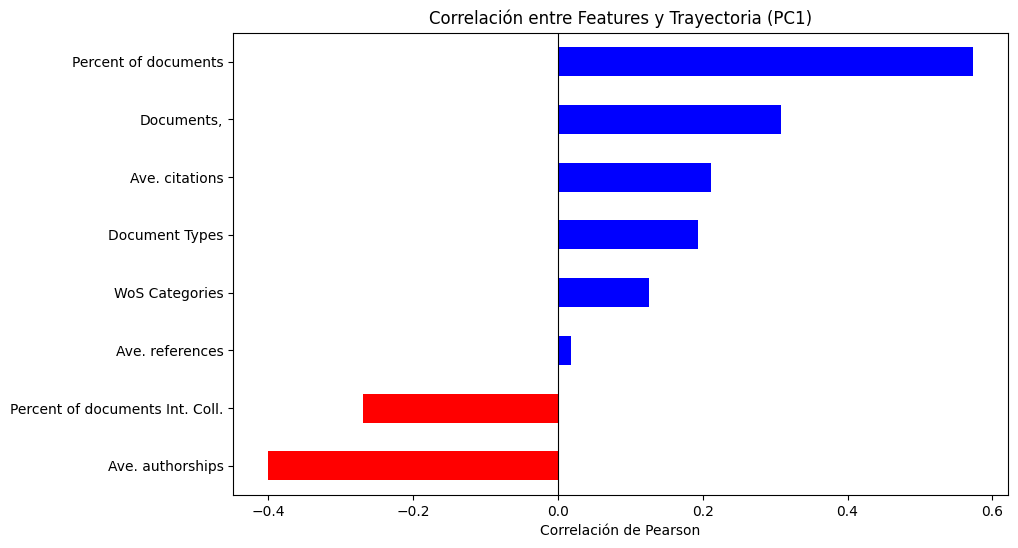

In [35]:
nombres_features = [f[1] for f in global_cfg.FEATURES]
df_features = eanalysis.obtener_promedios_anuales(df_flujo['year'].values, nombres_features, global_cfg.DATA_FOLDER)
df_flujo, correlaciones = eanalysis.correlacionar_y_alinear(df_flujo, df_features, ecfg.ALIGN_PC1_ANCHOR)

eviz.plot_correlaciones_barras(correlaciones)

In [36]:
print(df_features)

      WoS Categories  Document Types  Documents,  Ave. citations  \
1980        4.153846        1.538462    5.500000       25.557692   
1981        3.444444        1.428571    4.904762       26.207778   
1982        4.465517        1.465517    6.172414       87.475690   
1983        3.657143        1.371429    4.885714       48.827143   
1984        3.422222        1.466667    5.133333       38.730889   
1985        3.696970        1.454545    6.242424       29.730303   
1986        4.388889        1.388889   11.000000       24.320000   
1987        5.363636        1.835664    8.052448       40.816503   
1988        4.476562        1.625000    4.570312       39.999922   
1989        3.098361        1.327869    4.114754       20.946885   
1990        4.190476        1.523810    4.464286       42.731905   
1991        5.323770        1.803279    8.204918       26.269180   
1992        5.111607        1.691964    7.049107       30.247589   
1993        3.805825        1.533981    5.456311

In [37]:
#Percent of documents resultó  tener una correlación bastante alta, por lo tanto, las gráficas
#deberían ser bastante parecidas (la generada por pca y la que es a partir de los datos crudos)
#"Ave. authorships"
# 5. Gráficas de Comparación
df_plot, df_comparacion = eanalysis.preparar_datos_comparacion(df_features, df_flujo)
eviz.plot_feature_individual(df_plot, "Ave. authorships")
eviz.plot_comparacion_normalizada(df_comparacion)

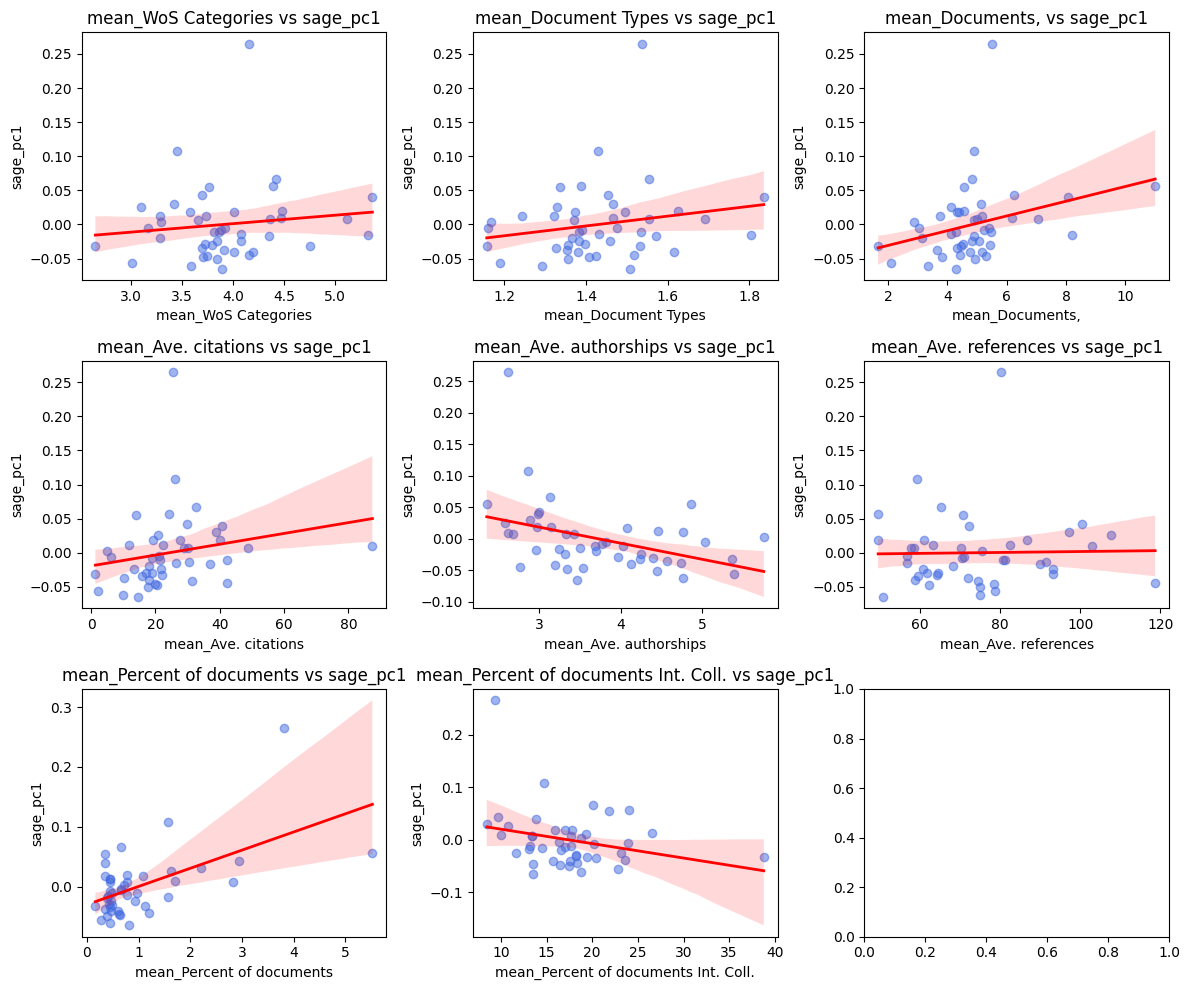

In [38]:
df_all = stat_analysis.cargar_y_unir_datos(cfg.LEVEL) #cargamos y preparamos los datos
#Exploración visual inicial
stat_viz.plot_dispersion_ols(df_all, 'mean_Percent of documents', 'sage_pc1')
# Los candidatos son exactamente los features definidos para hacer el embedding de sage
features_candidatas = [f"mean_{tupla[1]}" for tupla in global_cfg.FEATURES] # Extraemos el segundo elemento de la tupla (tupla[1]) y le pegamos "mean_"
stat_viz.plot_matriz_features(df_all, features_candidatas)

In [39]:
# Modelos OLS
# Múltiple sin HAC
modelo_mult = stat_analysis.ajustar_modelo_ols(df_all, 'sage_pc1', ['mean_Percent of documents', 'mean_Ave. citations', "mean_Ave. authorships"])
print(modelo_mult.summary())


#y = df_all['sage_pc1']  #variable objetivo
#X = df_all[['mean_Percent of documents', 'mean_Ave. authorships']] #Variables predictoras

# Le ponemos su constante 
#Ecuacion lineal de la forma y=b0 + b1x1 + b2x2 donde los xn son los atributos
#X = sm.add_constant(X) #cada atributo definido en X es un valor asociado a x_n, b0 es la constante (lo definimos como 1), b1 y b2 son los valores a estimar
#modelo = sm.OLS(y, X).fit()
#print(modelo.summary())

                            OLS Regression Results                            
Dep. Variable:               sage_pc1   R-squared:                       0.337
Model:                            OLS   Adj. R-squared:                  0.289
Method:                 Least Squares   F-statistic:                     6.961
Date:                Wed, 15 Apr 2026   Prob (F-statistic):           0.000682
Time:                        21:04:13   Log-Likelihood:                 76.663
No. Observations:                  45   AIC:                            -145.3
Df Residuals:                      41   BIC:                            -138.1
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                                coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------------
const                 

In [40]:

# Múltiple sin HAC

modelo_mult = stat_analysis.ajustar_modelo_ols(df_all, 'sage_pc1', ['mean_Percent of documents', 'mean_Ave. authorships', 'mean_WoS Categories',
                                                                    'mean_Document Types', 'mean_Documents,','mean_Ave. citations',
                                                                    'mean_Ave. references','mean_Percent of documents Int. Coll.'])
print(modelo_mult.summary())


                            OLS Regression Results                            
Dep. Variable:               sage_pc1   R-squared:                       0.404
Model:                            OLS   Adj. R-squared:                  0.271
Method:                 Least Squares   F-statistic:                     3.045
Date:                Wed, 15 Apr 2026   Prob (F-statistic):             0.0101
Time:                        21:04:13   Log-Likelihood:                 79.029
No. Observations:                  45   AIC:                            -140.1
Df Residuals:                      36   BIC:                            -123.8
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
                                           coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------------------


In [41]:
# Simple con HAC
modelo_simple = stat_analysis.ajustar_modelo_ols(df_all, 'sage_pc1', ['mean_Ave. authorships'], usar_hac=True, maxlags=3)
print(modelo_simple.summary())
#mean_Percent of documents

                            OLS Regression Results                            
Dep. Variable:               sage_pc1   R-squared:                       0.159
Model:                            OLS   Adj. R-squared:                  0.140
Method:                 Least Squares   F-statistic:                     5.139
Date:                Wed, 15 Apr 2026   Prob (F-statistic):             0.0285
Time:                        21:04:13   Log-Likelihood:                 71.309
No. Observations:                  45   AIC:                            -138.6
Df Residuals:                      43   BIC:                            -135.0
Df Model:                           1                                         
Covariance Type:                  HAC                                         
                            coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------
const                     0.09

------------------------------------------------------------
Diagnostico de residuos
------------------------------------------------------------
Prueba de Durbin-Watson (Independencia): 1.377
Prueba de Shapiro-Wilk (Normalidad): p-value = 0.0003
Prueba de Breusch-Pagan (Homocedasticidad): p-value = 0.0006


/home/jose/miniconda3/envs/pateaAbuelitas/lib/python3.10/site-packages/statsmodels/graphics/gofplots.py:1041: UserWarning:

color is redundantly defined by the 'color' keyword argument and the fmt string "b" (-> color=(0.0, 0.0, 1.0, 1)). The keyword argument will take precedence.



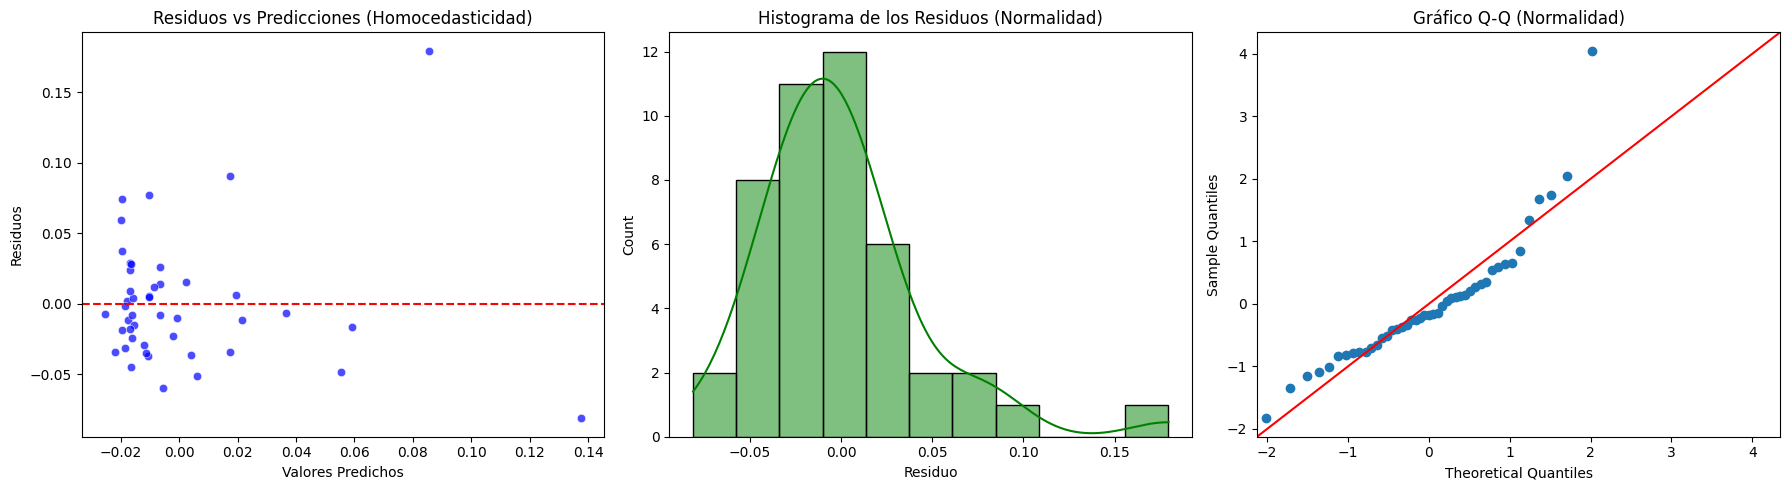

In [42]:
# Diagnóstico de residuos (del modelo simple normal para ver los errores puros)
modelo_base = stat_analysis.ajustar_modelo_ols(df_all, 'sage_pc1', ['mean_Percent of documents'])
residuos, predicciones = stat_analysis.ejecutar_diagnostico_residuos(modelo_base)

stat_viz.plot_panel_residuos(predicciones, residuos)
#stat_viz.plot_acf_residuos(df_all, residuos)

In [43]:
modelo_multiple = stat_analysis.ajustar_modelo_ols(
    df_all, 
    'sage_pc1', 
    ['mean_Percent of documents', 'mean_Ave. authorships'], 
    usar_hac=True, 
    maxlags=3
)
print(modelo_multiple.summary())

                            OLS Regression Results                            
Dep. Variable:               sage_pc1   R-squared:                       0.336
Model:                            OLS   Adj. R-squared:                  0.305
Method:                 Least Squares   F-statistic:                     3.980
Date:                Wed, 15 Apr 2026   Prob (F-statistic):             0.0261
Time:                        21:04:14   Log-Likelihood:                 76.621
No. Observations:                  45   AIC:                            -147.2
Df Residuals:                      42   BIC:                            -141.8
Df Model:                           2                                         
Covariance Type:                  HAC                                         
                                coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------------
const                 

  EXPERIMENTO E1: PCA sobre promedios bibliométricos directos

─────────────────────────────────────────────────────────────────
  Paso 1: PCA(mean(X_biblio) por año) → PC1_raw
─────────────────────────────────────────────────────────────────
[E1] Se invirtió PC1_raw para alinearlo con 'Percent of documents'. Corr original: -0.4414

  Varianza explicada por PC1_raw (EV1): 0.5047
  Features usadas: ['WoS Categories', 'Document Types', 'Documents,', 'Ave. citations', 'Ave. authorships', 'Ave. references', 'Percent of documents', 'Percent of documents Int. Coll.']
  Loadings de PC1_raw:
    WoS Categories                     : +0.3870
    Document Types                     : +0.4223
    Documents,                         : +0.3900
    Ave. citations                     : +0.3938
    Ave. authorships                   : -0.4421
    Ave. references                    : +0.0348
    Percent of documents               : +0.2196
    Percent of documents Int. Coll.    : -0.3461

────────────────

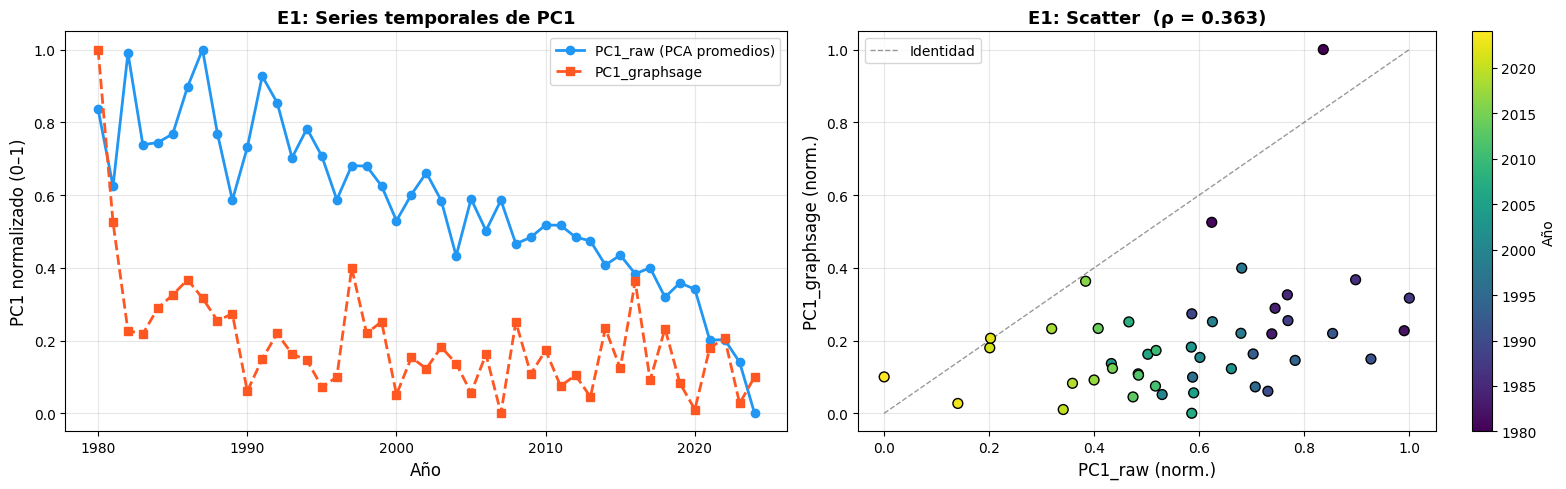

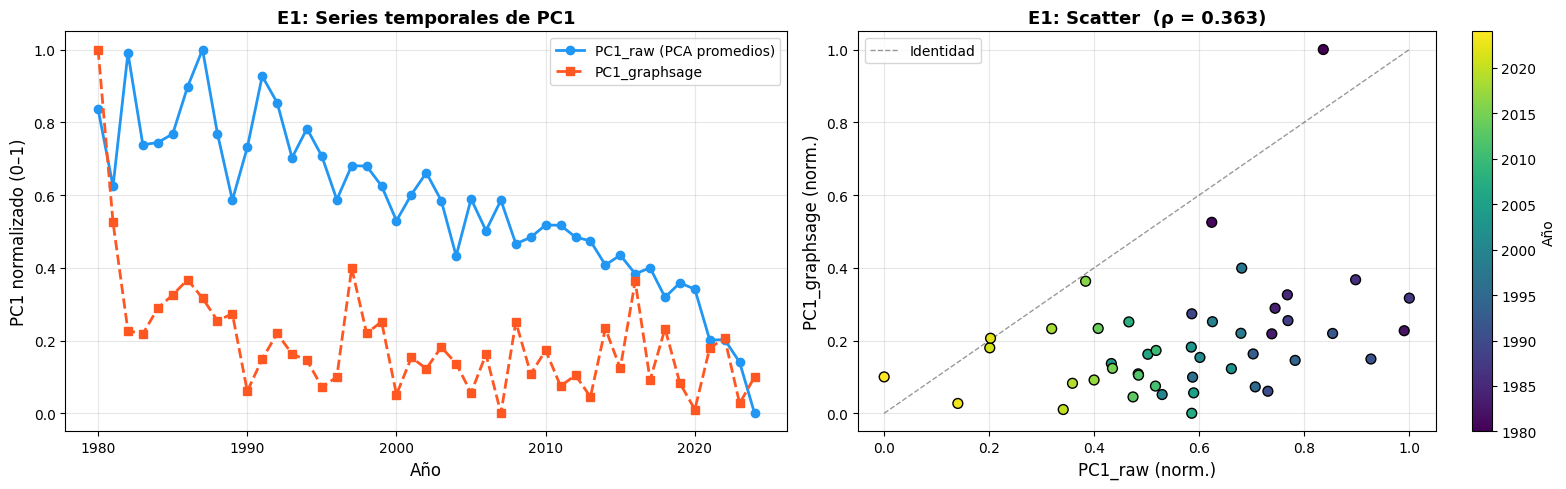

In [44]:
from src.baselines.e1_pca_promedios import ejecutar_e1
from src.baselines.visualization import plot_comparacion_pc1

# Ejecutar E1 completo (PCA sobre promedios → comparar con PC1 de GraphSAGE)
reporte_e1 = ejecutar_e1(df_features, df_flujo)

# Visualizar la comparación
plot_comparacion_pc1(reporte_e1["df_merged"])
